In [1]:
!pip install pandas numpy scikit-learn nltk

Defaulting to user installation because normal site-packages is not writeable


In [2]:
"done installation"

'done installation'

In [4]:
import pandas as pd

#load dataset
df=pd.read_csv(r"C:\Users\kasee\Downloads\IMDB Dataset.csv")
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [5]:
import pandas as pd
import re
import string
import nltk

from nltk.corpus import stopwords

# Download stopwords
nltk.download('stopwords')

# Remove duplicates
df = df.drop_duplicates()

# Stopwords
stop_words = set(stopwords.words('english'))

# Cleaning function
def clean_text(text):
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

# Apply cleaning
df['review'] = df['review'].apply(clean_text)

print(df.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kasee\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


                                              review sentiment
0  one reviewers mentioned watching 1 oz episode ...  positive
1  wonderful little production filming technique ...  positive
2  thought wonderful way spend time hot summer we...  positive
3  basically theres family little boy jake thinks...  negative
4  petter matteis love time money visually stunni...  positive


In [6]:
from nltk.corpus import stopwords

print(stopwords.words('english')[:10])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Features and Labels
X = df['review']
y = df['sentiment']

# Convert text into numerical vectors
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(X)

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = MultinomialNB()

# Train model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8585257638398709


In [9]:
# Test custom review

sample_review = ["This movie was absolutely fantastic and amazing"]

# Clean the review
sample_review_cleaned = [clean_text(review) for review in sample_review]

# Convert to vector
sample_vector = vectorizer.transform(sample_review_cleaned)

# Predict sentiment
prediction = model.predict(sample_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive


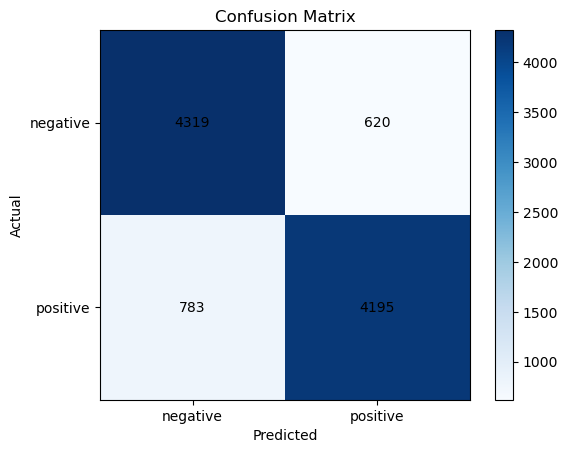

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

# Labels
plt.xticks([0,1], ['negative', 'positive'])
plt.yticks([0,1], ['negative', 'positive'])

# Numbers inside boxes
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center', color='black')

plt.show()

In [11]:
import pickle

# Save model
pickle.dump(model, open('sentiment_model.pkl', 'wb'))

# Save vectorizer
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))

print("Model and Vectorizer Saved Successfully!")

Model and Vectorizer Saved Successfully!


In [12]:
# User input prediction

user_review = input("Enter a movie review: ")

# Clean review
cleaned_review = clean_text(user_review)

# Convert to vector
review_vector = vectorizer.transform([cleaned_review])

# Predict
prediction = model.predict(review_vector)

print("Predicted Sentiment:", prediction[0])

Enter a movie review:  movie is with full of comedy and action


Predicted Sentiment: negative
